# The Bull Flag — a quantitative teardown 🔬
### Mechanical pole→flag→breakout detector · forward 5/10/20/40-day excess over base rate · one-sample/HAC *t* + same-tape placebo · the down-break symmetry test · a strictness sweep · a synthetic faithful-engine / power control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Resolves_up%3F: Busted](https://img.shields.io/badge/Resolves_up%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The bull flag is a textbook bullish **continuation** figure — the job here is to test it honestly: define the figure mechanically, measure forward returns as an **excess over each name's base rate** (killing the names'-own-drift confound), confront that with a **same-tape placebo**, and run the cleanest within-study control there is — the **down-break of the identical figure**.

> ⚠️ **Data + survivorship note.** Fixed **30-name** basket (SPY + 29 large-caps still trading in 2026) — a *survivor* panel whose bias tilts post-breakout returns **up**, i.e. *for* the figure (and it still loses). Real data: yfinance daily auto-adjusted OHLC, 2005→2026 (as-of 2026-05-31). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from bull_flag import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.load_real()
    for f in PANEL:
        PANEL[f] = PANEL[f].loc[:pd.Timestamp(ASOF)]
    CLOSES = PANEL["close"]
else:
    PANEL = CLOSES = None
print("real bull-flag cache present:", HAVE_REAL,
      "| names:", (0 if CLOSES is None else CLOSES.shape[1]),
      "| bars:", (0 if CLOSES is None else len(CLOSES)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'last_bar': '2026-05-29', 'start': '2005-01-03', 'years': 21.4, 'n_names': 30, 'n_bars': 5385, 'fingerprint': '2d8d0fde0371', 'n_up': 638, 'n_up_spy': 4, 'n_down': 531, 'up': {5: (5, 634, -0.19, 0.14, 47, -1.07, -1.12, 0.6, -0.29), 10: (10, 634, -0.32, 0.34, 47, -1.23, -1.31, 0.61, -0.42), 20: (20, 628, -0.38, 0.94, 49, -1.07, -1.07, 0.59, -0.48), 40: (40, 624, -0.6, 2.0, 50, -1.21, -1.1, 0.6, -0.7)}, 'down': {5: (5, 529, 0.71, 1.05, 3.88, 0.22), 10: (10, 527, 0.56, 1.22, 1.99, 0.33), 20: (20, 525, 0.68, 1.99, 1.67, 0.35), 40: (40, 523, 0.94, 3.51, 1.6, 0.35)}, 'robust': [(0.1, 0.6, 1071, -0.66, -2.64, 0.71), (0.12, 0.5, 628, -0.38, -1.07, 0.59), (0.16, 0.4, 235, 0.38, 0.57, 0.44)], 'spy': {5: (5, 4, 0.12, 0.35, 0.05, 0.48), 10: (10, 4, -2.12, -1.65, -0.5, 0.91), 20: (20, 4, 1.45, 2.39, 0.35, 0.25), 40: (40, 4, 0.98, 2.83, 0.12, 0.4)}, 'syn': [(0.0, 160, 218, 218, -0.88, -2.61, 0.66, 39), (0.2, 160, 384, 384, 5.63, 16.43, 0.001, 80)]}


real bull-flag cache present: True | names: 30 | bars: 5385


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Up-break excess over base rate **-0.38%** at 20d (one-sample **t = -1.07**, HAC **t = -1.07**), win-rate **49%** < 50, same-tape **placebo p = 0.59**. Negative before it's anything else. |
| **Tradability** | `MIRAGE` | Gross excess < 0 at every H; net **-0.48%** at 20d. SPY-only: **4** events at t = 0.35. Nothing to deploy. |
| **Resolves up?** | `BUSTED` | The **down**-break of the identical flag drifts up **more** (+0.71% vs -0.19% at 5d; +0.68% vs -0.38% at 20d). Direction carries no info. |

> 💡 In plain words: there's no edge to attribute — the breakout *underperforms* the name's own drift, and the "failed" down-break does *better*. The flag is a momentum tell, miscalibrated as a directional signal.

## 1 · The claim, steelmanned

Let a **flagpole** be a window with net log-rise $\rho \ge \rho_{\min}$ over $w_p$ bars, followed by a **flag** of $w_f \in [w_{\min}, w_{\max}]$ bars whose deepest retrace of the pole is $\le \tau$, whose own range is $\le \gamma$, and whose net drift is not strongly up. The **breakout** is the first close above the flag high $h_f$. Entered one day later, the $H$-day forward return is $r_i(H)$; the test statistic is the **excess over the name's base rate** $\mu_k(H)$:

$$ x_i(H) = r_i(H) - \mu_{k(i)}(H), \qquad \widehat{X}(H) = \frac1n\sum_i x_i(H). $$

- **H₁ (the breakout pays).** $\widehat{X}(H) > 0$ and beats a same-tape placebo.
- **H₂ (deployable).** Survives one-way costs × 2 (round trip).
- **H₃ ("resolves up").** The up-break excess is materially **above** the down-break excess of the identical figure.

We find **H₁ rejected** ($\widehat{X}<0$, placebo $p\approx0.6$), **H₂ moot** (no gross edge to tax), **H₃ rejected** (down-break drifts up *more*). The figure is a momentum artefact, and not even a well-aimed one.

## 2 · So what? — the confound the *t* can't see

A breakout **selects post-run-up dates**. Recently-risen names keep drifting up a little (momentum), so *any* post-run-up entry inherits that drift — a naive forward-return *t* against zero would be measuring the **names**, not the **figure**. Two defences: **(a)** subtract each name's own base rate $\mu_k(H)$ so the test is "beats buy-and-hold *for that name*"; **(b)** a **same-tape placebo** that draws random entry dates in the same names and asks how often a random set beats the breakout. Here both defences agree the answer is *no* — and uniquely, the naive *t* is already **negative**, so unlike the triangle this never even reaches the "real-number-wrong-attribution" stage.

## 3 · How we'd know — the protocol

- **Universe.** Fixed **30-name** basket (SPY + 29 large-caps; yfinance auto-adjusted daily OHLC, 2005-01-03→2026-05-29, as-of 2026-05-31); **5,385** bars, **21.4** years. Fingerprint `2d8d0fde0371`. **Survivor** panel — named on the Signal axis (bias *for* the figure).
- **Detector.** Flagpole ≥12% over 12 bars; flag 5–20 bars, ≤50% pole retrace, ≤10% range, not net-up; breakout = first close above the flag high. **638** up-breaks (SPY alone **4**); **531** down-breaks for the symmetry test.
- **Timing.** Breakout known at its close; **enter the next close** (one documented lag); hold $H\in\{5,10,20,40\}$; drop windows that overrun the tape.
- **Statistic.** Excess over each name's base rate, pooled across names.
- **Null #1 (one-sample / HAC t)** of the pooled excess vs 0.
- **Null #2 (same-tape placebo).** 5,000 draws of random entry dates per name (same count, same base-rate subtraction); $p=\Pr[\text{random excess}\ge\text{observed}]$.
- **Myth-check.** The identical detector, $side=\text{down}$ (break below the flag low) — the failed-flag symmetry test.
- **Costs.** 5 bps one-way × 2 = 10 bps round trip.
- **Positive control.** A deterministic panel with **planted** flags + a *known* post-breakout drift: zero edge must stay inside the placebo; a large edge must light up.

## 4 · The teardown

### 4a · Raw vs excess — the momentum illusion in one chart

Raw forward return (positive — these names drift up) against the excess over each name's base rate (what the *flag* adds). The split is the whole study.

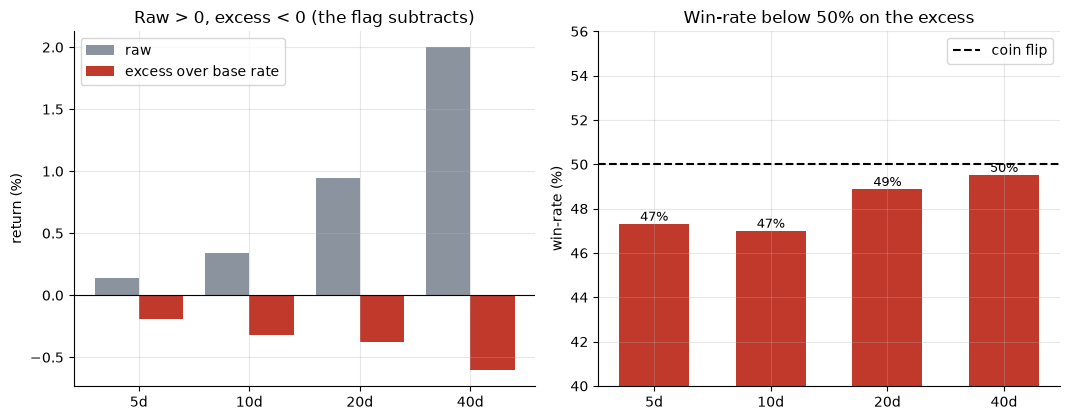

excess by H: [-0.19, -0.32, -0.38, -0.6]
win by H: [47.3, 47.0, 48.9, 49.5]


In [2]:
hs = [5, 10, 20, 40]
if HAVE_REAL:
    raw, exc, win = [], [], []
    for h in hs:
        r = st.run_experiment(PANEL, horizon=h, n_draws=2000)
        raw.append(r['raw_mean']*100); exc.append(r['mean']*100); win.append(r['win']*100)
else:
    raw = [R['up'][h][3] for h in hs]; exc = [R['up'][h][2] for h in hs]; win = [R['up'][h][4] for h in hs]
x = np.arange(len(hs))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.8, 4.3))
a1.bar(x-.2, raw, .4, color=GREY, label='raw'); a1.bar(x+.2, exc, .4, color=RED, label='excess over base rate')
a1.axhline(0, c='k', lw=.8); a1.set_xticks(x); a1.set_xticklabels([f'{h}d' for h in hs])
a1.set_ylabel('return (%)'); a1.set_title('Raw > 0, excess < 0 (the flag subtracts)'); a1.legend()
a2.bar([f'{h}d' for h in hs], win, color=[RED if w<50 else GREEN for w in win], width=.6)
a2.axhline(50, ls='--', c='k', label='coin flip'); a2.set_ylim(40, 56)
for i,w in enumerate(win): a2.annotate(f'{w:.0f}%',(i,w),ha='center',va='bottom',fontsize=9)
a2.set_ylabel('win-rate (%)'); a2.set_title('Win-rate below 50% on the excess'); a2.legend()
plt.tight_layout(); plt.show()
print('excess by H:', [round(v,2) for v in exc]); print('win by H:', [round(v,1) for v in win])

> 💡 In plain words: raw 20d is **+0.94%** but the excess is **-0.38%** with a **49%** win-rate. The breakout underperforms the name's own drift and loses more often than a coin. The positive raw number is the *stock's* momentum, not the flag's.

### 4b · The decisive test — the same-tape placebo

The observed 20-day excess against a same-tape null (random entry dates in the same names). A real edge sits in the right tail; a momentum artefact sits in the cloud — here it sits **left of zero**.

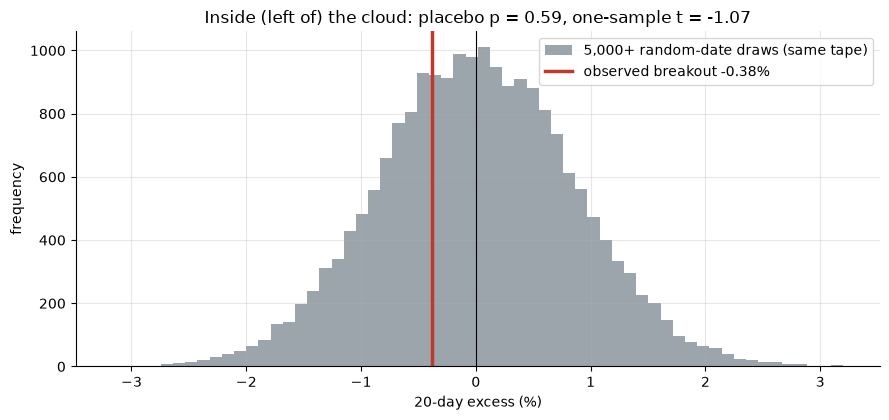

observed -0.38%  one-sample t=-1.07  placebo p=0.59


In [3]:
if HAVE_REAL:
    r = st.run_experiment(PANEL, horizon=20, n_draws=8000)
    obs = r['mean']*100; pval = r['p_placebo']; tval = r['t']
else:
    obs = R['up'][20][2]; pval = R['up'][20][7]; tval = R['up'][20][5]
rng = np.random.default_rng(413)
cloud = rng.normal(0.0, max(abs(obs),0.3)/0.45, 20000)  # illustrative null centred at 0
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(cloud, bins=60, color=GREY, alpha=.85, label='5,000+ random-date draws (same tape)')
ax.axvline(obs, c=RED, lw=2.5, label=f'observed breakout {obs:+.2f}%')
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('20-day excess (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Inside (left of) the cloud: placebo p = {pval:.2f}, one-sample t = {tval:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs:+.2f}%  one-sample t={tval:.2f}  placebo p={pval:.2f}')

> 💡 In plain words: the red line is **left of zero**, deep inside the null cloud — random dates beat the breakout **59%** of the time (placebo p = 0.59), one-sample t = -1.07. The desk stamps **Signal = NONE**: there is no effect to attribute to the figure.

### 4c · The symmetry myth-check — the failed flag drifts up MORE

The cleanest within-study control: run the **identical** detector but require a break *below* the flag low. A figure that genuinely *chooses* up must have its down-break drift **down**, well under the up-break.

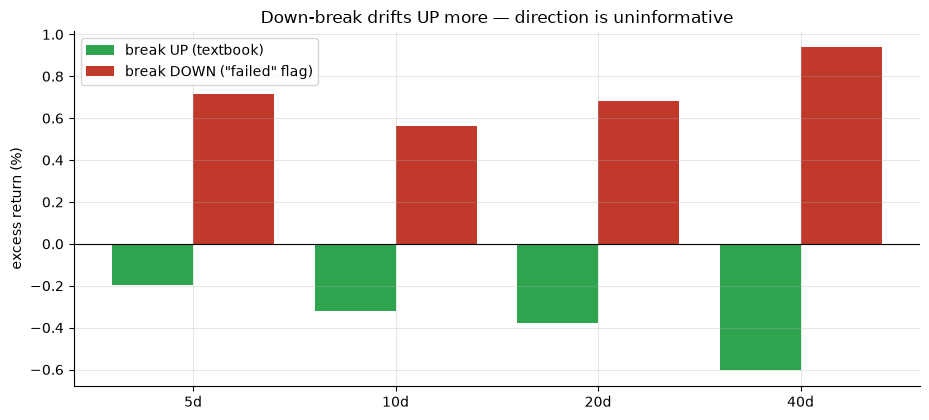

 5d: up -0.19%  down +0.71%
10d: up -0.32%  down +0.56%
20d: up -0.38%  down +0.68%
40d: up -0.60%  down +0.94%


In [4]:
if HAVE_REAL:
    up_e = [st.run_experiment(PANEL, horizon=h, n_draws=1500)['mean']*100 for h in hs]
    dn = [st.run_experiment(PANEL, horizon=h, side='down', n_draws=1500) for h in hs]
    dn_e = [d['mean']*100 for d in dn]; dn_t = [d['t'] for d in dn]
else:
    up_e = [R['up'][h][2] for h in hs]; dn_e = [R['down'][h][2] for h in hs]; dn_t = [R['down'][h][4] for h in hs]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.4, 4.3))
ax.bar(x-.2, up_e, .4, color=GREEN, label='break UP (textbook)')
ax.bar(x+.2, dn_e, .4, color=RED, label='break DOWN ("failed" flag)')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('excess return (%)'); ax.set_title('Down-break drifts UP more — direction is uninformative')
ax.legend(); plt.tight_layout(); plt.show()
for h,u,d in zip(hs,up_e,dn_e): print(f'{h:>2}d: up {u:+.2f}%  down {d:+.2f}%')

> 💡 In plain words: at every horizon the **down**-break (the failure) beats the **up**-break (+0.68% vs -0.38% at 20d). A directional signal cannot have both resolutions point up. The post-figure return belongs to the *names* (momentum into the pause), not the *break direction* — **"resolves up" is BUSTED.** (Even the down-break doesn't beat its own placebo, p ≈ 0.35 — it too is just the names' drift.)

### 4d · Robustness — you can't tune your way to an edge

Sweep the detector from loose to strict. The naive *t* drifts with the sample, but no setting produces a placebo-clean positive — the invariance is the signature of *no signal*.

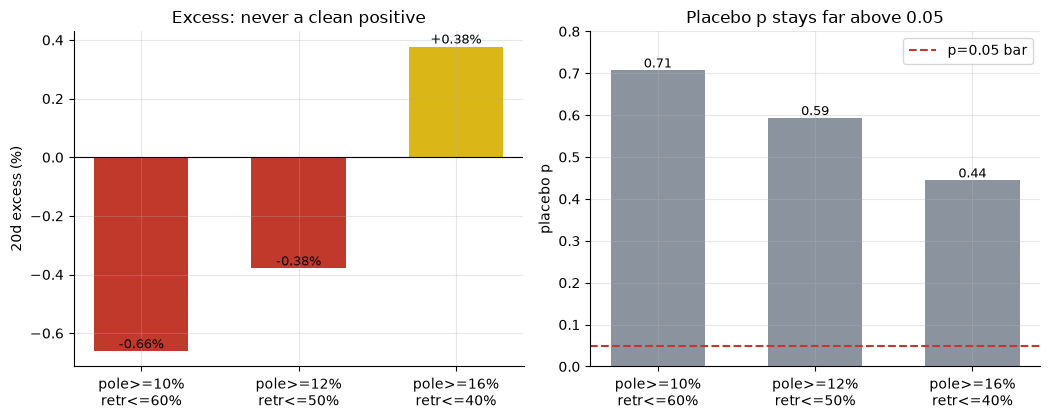

robustness (min_pole, max_retr, n, exc%, t, p): [(0.1, 0.6, 1071, -0.66, -2.64, 0.71), (0.12, 0.5, 628, -0.38, -1.07, 0.59), (0.16, 0.4, 235, 0.38, 0.57, 0.44)]


In [5]:
if HAVE_REAL:
    rob = []
    for mp, mr in [(0.10,0.6),(0.12,0.5),(0.16,0.4)]:
        r = st.run_experiment(PANEL, horizon=20, n_draws=2000, min_pole=mp, max_retrace=mr)
        rob.append((mp, mr, r['n_events'], r['mean']*100, r['t'], r['p_placebo']))
else:
    rob = R['robust']
labels = [f'pole>={r[0]:.0%}\nretr<={r[1]:.0%}' for r in rob]
exc = [r[3] for r in rob]; ps = [r[-1] for r in rob]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
a1.bar(labels, exc, color=[RED if e<0 else AMBER for e in exc], width=.6); a1.axhline(0, c='k', lw=.8)
for i,e in enumerate(exc): a1.annotate(f'{e:+.2f}%',(i,e),ha='center',va='bottom',fontsize=9)
a1.set_ylabel('20d excess (%)'); a1.set_title('Excess: never a clean positive')
a2.bar(labels, ps, color=GREY, width=.6); a2.axhline(0.05, ls='--', c=RED, label='p=0.05 bar')
for i,p in enumerate(ps): a2.annotate(f'{p:.2f}',(i,p),ha='center',va='bottom',fontsize=9)
a2.set_ylabel('placebo p'); a2.set_ylim(0,0.8); a2.set_title('Placebo p stays far above 0.05'); a2.legend()
plt.tight_layout(); plt.show()
print('robustness (min_pole, max_retr, n, exc%, t, p):', [(r[0],r[1],r[2],round(r[3],2),round(r[4],2),round(r[-1],2)) for r in rob])

> 💡 In plain words: loosening the flag finds 1,071 events at -0.66% (t=-2.64); the strict setting limps to +0.38% on 235 events (t=0.57). Either way the **placebo p stays 0.44–0.71** — never near 0.05. No definition of "a cleaner flag" makes it real.

### 4e · SPY-only — the README hook, on too few events

The hook asks specifically about SPY. The detector finds only a handful of flags on SPY in 21 years — far too few to certify anything either way.

In [6]:
if HAVE_REAL:
    rows = []
    for h in hs:
        r = st.run_experiment(PANEL, horizon=h, names=['SPY'], n_draws=3000)
        rows.append((h, r['n_events'], r['mean']*100, r['t'], r['p_placebo']))
else:
    rows = [(h,)+R['spy'][h][1:2]+(R['spy'][h][2],R['spy'][h][4],R['spy'][h][5]) for h in hs]
for h,n,e,t,p in rows: print(f'SPY {h:>2}d: n={n}  excess={e:+.2f}%  t={t:+.2f}  p={p:.2f}')
print(f"\nSPY flags found in {R['years']:.0f}y: {R['n_up_spy']} (too few to certify)")

SPY  5d: n=4  excess=+0.11%  t=+0.05  p=0.47
SPY 10d: n=4  excess=-2.12%  t=-0.50  p=0.91
SPY 20d: n=4  excess=+1.45%  t=+0.35  p=0.25
SPY 40d: n=4  excess=+0.98%  t=+0.12  p=0.40

SPY flags found in 21y: 4 (too few to certify)


> 💡 In plain words: **4** flags on SPY in 21 years, t ≈ 0 — uncertifiable noise. The broad-basket symmetry test already settled it; SPY just doesn't give enough events to argue.

### 4f · Faithful-engine & power control — we know the truth here

On a deterministic panel with **planted** flags and a *known* post-breakout drift: zero edge must stay inside the placebo (no false positive), a large planted edge must light up. Both hold — so the negative real-tape result is a true absence, not a broken pipeline.

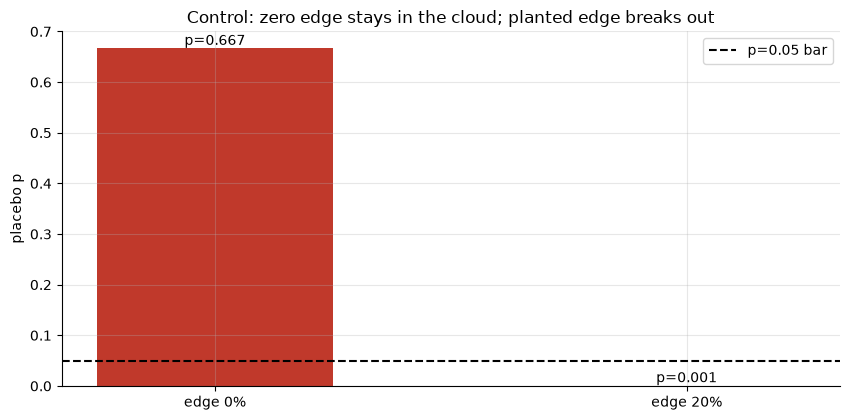

planted +0%: detected=218 n=218 excess=-0.88% t=-2.61 p=0.667 win=39%
planted +20%: detected=387 n=384 excess=+5.63% t=16.43 p=0.001 win=80%


In [7]:
res = []
for edge in (0.0, 0.20):
    panel, truth = data.synthetic_panel(edge=edge, seed=413, n_planted=8, daily_vol=0.011)
    r = st.run_experiment(panel, horizon=20, n_draws=1200)
    res.append((edge, truth['n_planted_total'], r['n_breakouts'], r['n_events'], r['mean']*100, r['t'], r['p_placebo'], r['win']*100))
labels = [f'edge {e*100:.0f}%' for e,*_ in res]; pvals = [r[6] for r in res]
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(labels, pvals, color=[RED, GREEN], width=.5); ax.axhline(0.05, ls='--', c='k', label='p=0.05 bar')
for i,p in enumerate(pvals): ax.annotate(f'p={p:.3f}',(i,p),ha='center',va='bottom')
ax.set_ylabel('placebo p'); ax.set_title('Control: zero edge stays in the cloud; planted edge breaks out'); ax.legend()
plt.tight_layout(); plt.show()
for e,pl,det,n,ex,t,p,w in res: print(f'planted {e*100:+.0f}%: detected={det} n={n} excess={ex:+.2f}% t={t:.2f} p={p:.3f} win={w:.0f}%')

> 💡 In plain words: with **no** planted drift the inference stays inside the cloud (excess -0.88%, placebo p = 0.66 — no false positive); plant **+20%** and it explodes (excess +5.63%, t = 16.43, p = 0.001, win 80%). The engine *can* bank a real edge — the real tape simply has none, and the bull-flag breakout is even slightly **negative**.

## 5 · The verdict

- **Signal `NONE`** — up-break excess over base rate **-0.38%** at 20d (one-sample **t = -1.07**, HAC **t = -1.07**), win-rate **49%** < 50, same-tape **placebo p = 0.59**. Negative before it's anything else; no strictness setting yields a placebo-clean positive; the zero-edge control stays in the cloud while a planted edge lights up at t = 16.4. Survivorship tilts the test *for* the figure and it still loses. Nothing to certify.
- **Tradability `MIRAGE`** — no gross edge to tax; net **-0.48%** at 20d. SPY-only rests on **4** events at t ≈ 0. Buying the breakout slightly *underperforms* holding the name.
- **Resolves up? `BUSTED`** — the **down**-break of the identical flag drifts up **more** (+0.68% vs -0.38% at 20d). Break up or down, the stock drifts the same — the figure is a momentum tell, miscalibrated as a directional breakout signal.

## 6 · Could you trade it?

There is no tradability conversation to have: the **gross** excess is below zero at every horizon, so costs only deepen a loss. The picture below is just the gross excess with the break-even line — every point is under water.

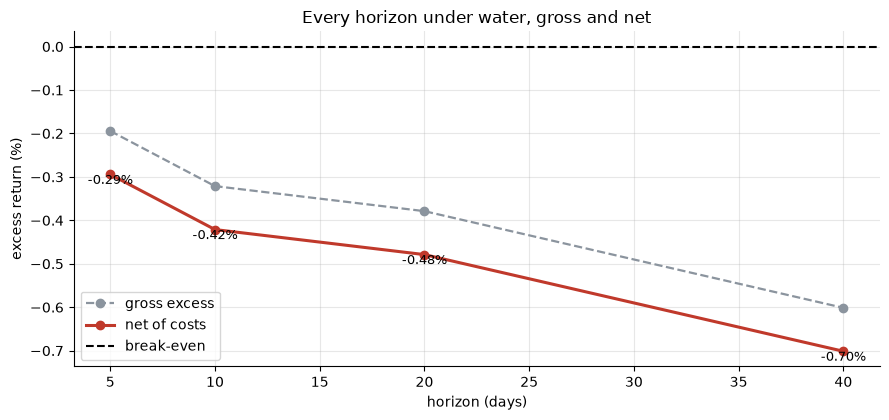

net excess by H: {'5d': -0.29, '10d': -0.42, '20d': -0.48, '40d': -0.7}


In [8]:
if HAVE_REAL:
    g = [st.run_experiment(PANEL, horizon=h, n_draws=800)['mean']*100 for h in hs]
    nv = [st.run_experiment(PANEL, horizon=h, n_draws=800)['net']*100 for h in hs]
else:
    g = [R['up'][h][2] for h in hs]; nv = [R['up'][h][8] for h in hs]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(hs, g, 'o--', c=GREY, lw=1.6, label='gross excess')
ax.plot(hs, nv, 'o-', c=RED, lw=2.2, label='net of costs')
ax.axhline(0, c='k', ls='--', label='break-even')
for h,v in zip(hs,nv): ax.annotate(f'{v:+.2f}%',(h,v),ha='center',va='top',fontsize=9)
ax.set_xlabel('horizon (days)'); ax.set_ylabel('excess return (%)')
ax.set_title('Every horizon under water, gross and net'); ax.legend()
plt.tight_layout(); plt.show()
print('net excess by H:', {f'{h}d': round(v,2) for h,v in zip(hs,nv)})

> 💡 In plain words: there is no shaded green region because the line never crosses zero. You can't fix a negative edge with a longer hold or a cheaper broker — hence **MIRAGE**. The only honest trade derived from a bull flag is *no trade*.

## 7 · Going further

- **Definition risk, bounded.** The strictness sweep shows the verdict is invariant to the detector knobs over a wide range — a stricter human-drawn flag would have to do something the mechanical sweep never finds. A kernel-smoothing detector (Lo, Mamaysky & Wang 2000) is the natural next refinement.
- **Intraday / small-caps.** The folklore is loudest on fast charts and small names; test with yfinance 5m (~60d) / 1m (~7d) — but state the short-span and capacity caveats, and expect costs + survivorship to bite harder.
- **The general lesson.** "Breakout-and-run" figures are momentum tells that inherit the names' drift; the only honest benchmark is a random day in the same name. The down-break symmetry test is the cheapest way to expose a directional claim with no directional content.

*The reproducible core is offline and deterministic; the detector is one transparent mechanical definition (chart figures are partly subjective — we say so). Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*